# Hafta 10: Protein Yapısı ve Bio.PDB: Koordinatlar, Geometri, Temas Haritaları

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. Protein yapısının dört düzeyini ve yapı belirleme yöntemlerini tanımak.
2. PDB dosya formatını ve Biopython'un **SMCRA** (Structure–Model–Chain–Residue–Atom) hiyerarşisini kullanmak.
3. Atomlar arası uzaklık, açı, dihedral (φ/ψ) hesaplamak; Ramachandran grafiği çizmek.
4. Temas haritası, ağırlık merkezi, dönme yarıçapı ve RMSD (üst üste çakıştırma) hesaplamak.

**Veri:** `1A8O.pdb` — HIV-1 kapsid proteininin C-uç domeni (X-ışını, 1.7 Å). Colab'da RCSB PDB'den otomatik indirilir.

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython py3Dmol
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
import os, urllib.request
os.makedirs("veri", exist_ok=True)
if not os.path.exists("veri/1A8O.pdb"):
    urllib.request.urlretrieve("https://files.rcsb.org/download/1A8O.pdb", "veri/1A8O.pdb")
print("dosya boyutu:", os.path.getsize("veri/1A8O.pdb"), "bayt")

dosya boyutu: 83024 bayt


## 1. Protein yapısının düzeyleri ve yapı belirleme

| Düzey | Tanım | Örnek |
|---|---|---|
| Birincil | Amino asit dizisi | `MDIRQGPKEP...` |
| İkincil | Yerel düzenli yapılar | α-heliks, β-tabaka, kıvrım |
| Üçüncül | Tek zincirin 3B katlanması | Domen yapısı |
| Dördüncül | Birden fazla zincirin birleşimi | Hemoglobin (α₂β₂) |

| Yöntem | Çözünürlük | Not |
|---|---|---|
| X-ışını kristalografisi | ~1–3 Å | Kristal gerekir; PDB'nin çoğunluğu |
| NMR | — | Çözeltide, küçük proteinler, birden fazla *model* |
| Kriyo-EM | ~2–4 Å | Büyük kompleksler |
| AlphaFold (tahmin) | — | pLDDT güven skoru B-faktörü sütununda |

## 2. PDB formatı: ATOM satırı (sabit sütunlu)
```
ATOM     10  CA  ASP A 152      21.835  36.306  28.144  1.00 20.88           C
```
| Sütunlar | Alan | Örnek |
|---|---|---|
| 1–6 | Kayıt tipi | `ATOM` / `HETATM` |
| 13–16 | Atom adı | `CA` (α-karbonu) |
| 18–20 | Kalıntı adı | `ASP` |
| 22 | Zincir | `A` |
| 23–26 | Kalıntı numarası | `152` |
| 31–54 | x, y, z (Å) | `21.835 36.306 28.144` |
| 55–60 | Doluluk (occupancy) | `1.00` |
| 61–66 | Sıcaklık faktörü (B) | `20.88` |

In [3]:
satirlar = open("veri/1A8O.pdb").read().splitlines()
for s in satirlar:
    if s.startswith(("HEADER", "TITLE", "EXPDTA", "HELIX")) or s.startswith("REMARK   2 RES"):
        print(s)
atomlar = [s for s in satirlar if s.startswith("ATOM")]
print("\nİlk iki ATOM satırı:\n" + atomlar[0] + "\n" + atomlar[1])
s = atomlar[1]
print("\nElle ayrıştırma -> atom:", s[12:16].strip(), "| kalıntı:", s[17:20], "| zincir:", s[21],
      "| no:", int(s[22:26]), "| xyz:", float(s[30:38]), float(s[38:46]), float(s[46:54]), "| B:", float(s[60:66]))

HEADER    VIRAL PROTEIN                           27-MAR-98   1A8O              
TITLE     HIV CAPSID C-TERMINAL DOMAIN                                          
EXPDTA    X-RAY DIFFRACTION                                                     
REMARK   2 RESOLUTION.    1.70 ANGSTROMS.                                       
HELIX    1   1 PHE A  161  GLU A  175  1                                  15    
HELIX    2   2 GLN A  179  GLU A  187  1                                   9    
HELIX    3   3 LEU A  189  GLN A  192  1                                   4    
HELIX    4   4 PRO A  196  LEU A  205  1                                  10    
HELIX    5   5 LEU A  211  ALA A  217  1                                   7    

İlk iki ATOM satırı:
ATOM     90  N   ASP A 152      21.554  34.953  27.691  1.00 19.26           N  
ATOM     10  CA  ASP A 152      21.835  36.306  28.144  1.00 20.88           C 

Elle ayrıştırma -> atom: CA | kalıntı: ASP | zincir: A | no: 152 | xyz: 21.835 36.306 2

## 3. SMCRA hiyerarşisi
```
Structure (1A8O)
 └── Model 0
      └── Chain A
           ├── Residue (' ', 152, ' ')  ASP
           │     ├── Atom N
           │     ├── Atom CA
           │     └── ...
           ├── Residue ('H_MSE', 151, ' ')  selenometiyonin (hetero kalıntı)
           └── Residue ('W', 1, ' ')  su molekülü
```
Kalıntı kimliği üçlüdür: (hetero bayrağı, sıra numarası, insersiyon kodu).

In [4]:
from Bio.PDB import PDBParser
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import Counter

yapi = PDBParser(QUIET=True).get_structure("1A8O", "veri/1A8O.pdb")
for model in yapi:
    for zincir in model:
        tipler = Counter(r.id[0] for r in zincir)
        print(f"Model {model.id}, Zincir {zincir.id}: {len(zincir)} kalıntı -> standart={tipler[' ']}, "
              f"hetero(MSE)={tipler['H_MSE']}, su={tipler['W']}")
print("Toplam atom:", len(list(yapi.get_atoms())))
zincir = yapi[0]["A"]
k = zincir[152]
print("Kalıntı 152:", k.get_resname(), "| atomları:", [a.get_id() for a in k])
print("CA koordinatı:", k["CA"].coord, "| B-faktörü:", k["CA"].get_bfactor())

Model 0, Zincir A: 158 kalıntı -> standart=66, hetero(MSE)=4, su=88
Toplam atom: 644
Kalıntı 152: ASP | atomları: ['N', 'CA', 'C', 'O', 'CB', 'CG', 'OD1', 'OD2']
CA koordinatı: [21.835 36.306 28.144] | B-faktörü: 20.88


In [5]:
from Bio.PDB import PPBuilder, is_aa
from Bio.SeqUtils import seq1

# PPBuilder hetero kalıntılarda (MSE) zinciri böler:
for pp in PPBuilder().build_peptides(yapi):
    print(f"peptit {pp[0].id[1]}-{pp[-1].id[1]}: {pp.get_sequence()}")

# Selenometiyonini metiyonin (M) sayarak tam diziyi çıkaralım
kalintilar = [r for r in zincir if is_aa(r, standard=False)]
dizi = seq1("".join(r.get_resname() for r in kalintilar), custom_map={"MSE": "M"})
print(f"\nTam dizi ({len(dizi)} aa, kalıntı {kalintilar[0].id[1]}-{kalintilar[-1].id[1]}):\n{dizi}")

peptit 152-184: DIRQGPKEPFRDYVDRFYKTLRAEQASQEVKNW
peptit 186-213: TETLLVQNANPDCKTILKALGPGATLEE
peptit 216-220: TACQG

Tam dizi (70 aa, kalıntı 151-220):
MDIRQGPKEPFRDYVDRFYKTLRAEQASQEVKNWMTETLLVQNANPDCKTILKALGPGATLEEMMTACQG


## 4. Geometri: uzaklık, açı, dihedral

**Uzaklık:** $d = \sqrt{(x_2-x_1)^2+(y_2-y_1)^2+(z_2-z_1)^2}$

**Sayısal örnek:** A = (1, 2, 3), B = (4, 6, 3) → $d = \sqrt{9 + 16 + 0} = 5$ Å.

**Açı:** $\cos\theta = \dfrac{\vec{u}\cdot\vec{v}}{|\vec{u}||\vec{v}|}$

**Dihedral (burulma) açısı:** Dört atomun (A–B–C–D) tanımladığı iki düzlem arasındaki açı. Omurgada:
φ: C(i−1)–N–Cα–C, ψ: N–Cα–C–N(i+1). α-heliks: φ ≈ −60°, ψ ≈ −45°; β-tabaka: φ ≈ −120°, ψ ≈ +130°.

In [6]:
from Bio.PDB.vectors import Vector, calc_angle, calc_dihedral

A, B = np.array([1, 2, 3.]), np.array([4, 6, 3.])
print("Örnek uzaklık:", np.linalg.norm(B - A))

ca1, ca2 = zincir[160]["CA"], zincir[161]["CA"]
print(f"Ardışık CA-CA uzaklığı (160-161): {ca1 - ca2:.2f} Å  (beklenen ≈ 3.8 Å)")

r = zincir[170]
aci = calc_angle(r["N"].get_vector(), r["CA"].get_vector(), r["C"].get_vector())
print(f"N-CA-C bağ açısı (170): {np.degrees(aci):.1f}°  (beklenen ≈ 111°)")

onceki, sonraki = zincir[169], zincir[171]
phi = calc_dihedral(onceki["C"].get_vector(), r["N"].get_vector(), r["CA"].get_vector(), r["C"].get_vector())
psi = calc_dihedral(r["N"].get_vector(), r["CA"].get_vector(), r["C"].get_vector(), sonraki["N"].get_vector())
print(f"Kalıntı 170: φ = {np.degrees(phi):.1f}°, ψ = {np.degrees(psi):.1f}°  -> heliks bölgesinde (161-175)")

Örnek uzaklık: 5.0
Ardışık CA-CA uzaklığı (160-161): 3.82 Å  (beklenen ≈ 3.8 Å)
N-CA-C bağ açısı (170): 106.0°  (beklenen ≈ 111°)
Kalıntı 170: φ = -67.6°, ψ = -42.9°  -> heliks bölgesinde (161-175)


In [7]:
# Kendi dihedral fonksiyonumuz (vektör cebiri)
def dihedral(p0, p1, p2, p3):
    b0, b1, b2 = p0 - p1, p2 - p1, p3 - p2
    b1 = b1 / np.linalg.norm(b1)
    v = b0 - np.dot(b0, b1) * b1
    w = b2 - np.dot(b2, b1) * b1
    x = np.dot(v, w); y = np.dot(np.cross(b1, v), w)
    return np.degrees(np.arctan2(y, x))

print("Kendi fonksiyonumuz: φ =", round(dihedral(onceki["C"].coord, r["N"].coord, r["CA"].coord, r["C"].coord), 1))

Kendi fonksiyonumuz: φ = -67.6


## 5. Ramachandran grafiği

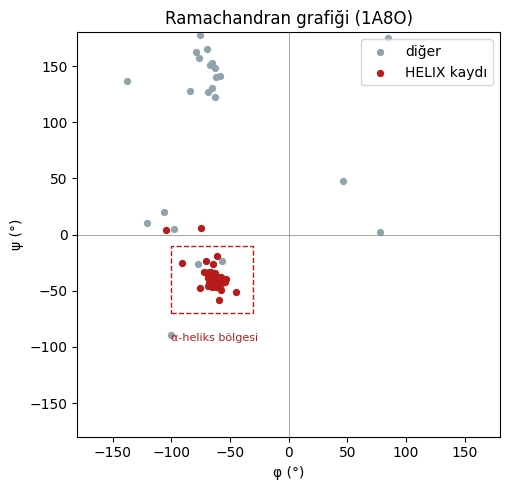

Heliks kayıtlarındaki kalıntıların ortalama φ/ψ: {'phi': -65.0, 'psi': -37.9}


In [8]:
heliksler = []
for s in satirlar:
    if s.startswith("HELIX"):
        heliksler.append((int(s[21:25]), int(s[33:37])))
heliks_mi = lambda n: any(a <= n <= b for a, b in heliksler)

phi_psi = []
# PPBuilder bölünmelerini önlemek için ardışık kalıntılardan kendimiz hesaplayalım
for i in range(1, len(kalintilar) - 1):
    o, r, s_ = kalintilar[i - 1], kalintilar[i], kalintilar[i + 1]
    if s_.id[1] - o.id[1] != 2:
        continue
    phi = calc_dihedral(o["C"].get_vector(), r["N"].get_vector(), r["CA"].get_vector(), r["C"].get_vector())
    psi = calc_dihedral(r["N"].get_vector(), r["CA"].get_vector(), r["C"].get_vector(), s_["N"].get_vector())
    phi_psi.append((r.id[1], r.get_resname(), np.degrees(phi), np.degrees(psi), heliks_mi(r.id[1])))
df = pd.DataFrame(phi_psi, columns=["no", "kalinti", "phi", "psi", "heliks"])

plt.figure(figsize=(5.2, 5))
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.scatter(df[~df.heliks].phi, df[~df.heliks].psi, s=18, color="#90a4ae", label="diğer")
plt.scatter(df[df.heliks].phi, df[df.heliks].psi, s=18, color="#b71c1c", label="HELIX kaydı")
plt.gca().add_patch(plt.Rectangle((-100, -70), 70, 60, fill=False, ls="--", color="#b71c1c"))
plt.text(-100, -95, "α-heliks bölgesi", color="#b71c1c", fontsize=8)
plt.xlim(-180, 180); plt.ylim(-180, 180); plt.xlabel("φ (°)"); plt.ylabel("ψ (°)")
plt.title("Ramachandran grafiği (1A8O)"); plt.legend(loc="upper right"); plt.tight_layout(); plt.show()
print("Heliks kayıtlarındaki kalıntıların ortalama φ/ψ:", df[df.heliks][["phi", "psi"]].mean().round(1).to_dict())

## 6. Temas haritası (contact map)
Cα atomları arası uzaklık < 8 Å olan kalıntı çiftleri "temas" kabul edilir. Heliksler köşegene paralel bantlar,
β-tabakalar köşegene dik/paralel çizgiler olarak görünür. Temas haritaları yapı tahmininde (AlphaFold dahil) temel çıktılardan biridir.

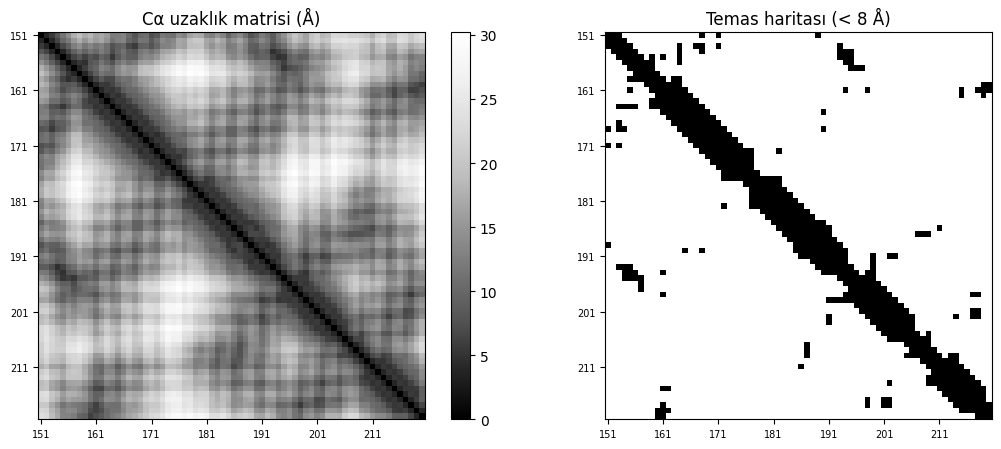

Kalıntı başına ortalama temas sayısı: 8.3


In [9]:
CA = np.array([r["CA"].coord for r in kalintilar])
Dm = np.sqrt(((CA[:, None, :] - CA[None, :, :]) ** 2).sum(-1))       # NumPy yayını (broadcasting)
temas = Dm < 8.0
fig, ax = plt.subplots(1, 2, figsize=(11, 4.6))
im = ax[0].imshow(Dm, cmap="Greys_r"); ax[0].set_title("Cα uzaklık matrisi (Å)"); plt.colorbar(im, ax=ax[0])
ax[1].imshow(temas, cmap="Greys"); ax[1].set_title("Temas haritası (< 8 Å)")
for a in ax:
    t = list(range(0, len(kalintilar), 10))
    a.set_xticks(t); a.set_xticklabels([kalintilar[i].id[1] for i in t], fontsize=7)
    a.set_yticks(t); a.set_yticklabels([kalintilar[i].id[1] for i in t], fontsize=7)
plt.tight_layout(); plt.show()
print("Kalıntı başına ortalama temas sayısı:", round((temas.sum(1) - 1).mean(), 1))

In [10]:
from Bio.PDB import NeighborSearch
atomlar_prot = [a for a in yapi.get_atoms() if a.get_parent().id[0] != "W"]
ns = NeighborSearch(atomlar_prot)
cysler = [r for r in kalintilar if r.get_resname() == "CYS"]
print("Sisteinler:", [c.id[1] for c in cysler])
if len(cysler) >= 2:
    d = cysler[0]["SG"] - cysler[1]["SG"]
    print(f"SG-SG uzaklığı: {d:.2f} Å -> disülfit bağı {'VAR' if d < 2.3 else 'YOK'} (eşik ≈ 2.05 Å)")
yakin = ns.search(cysler[0]["SG"].coord, 6.0, level="R")
print(f"CYS{cysler[0].id[1]} SG atomuna 6 Å içindeki kalıntılar:", sorted(r.id[1] for r in yakin))

Sisteinler: [198, 218]
SG-SG uzaklığı: 2.04 Å -> disülfit bağı VAR (eşik ≈ 2.05 Å)
CYS198 SG atomuna 6 Å içindeki kalıntılar: [155, 161, 194, 195, 197, 198, 199, 201, 202, 214, 217, 218]


## 7. Global özellikler: ağırlık merkezi, dönme yarıçapı, B-faktörleri
**Dönme yarıçapı (radius of gyration):** $R_g = \sqrt{\dfrac{1}{N}\sum_i \lVert \mathbf{r}_i - \mathbf{r}_{merkez}\rVert^2}$ — proteinin ne kadar kompakt olduğunu ölçer.
Küresel proteinler için kabaca $R_g \approx 2.2\,N^{0.38}$ Å (N: kalıntı sayısı).

Cα ağırlık merkezi: [18.37 36.04 15.92]
Rg = 11.13 Å | küresel protein beklentisi 2.2·N^0.38 = 11.06 Å (N=70)


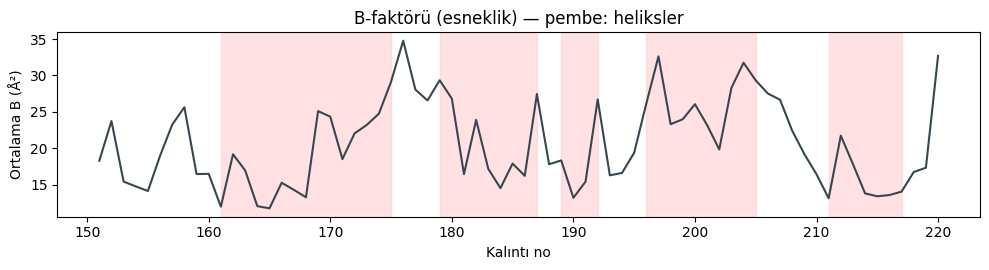

In [11]:
merkez = CA.mean(axis=0)
Rg = np.sqrt(((CA - merkez) ** 2).sum(1).mean())
print(f"Cα ağırlık merkezi: {merkez.round(2)}")
print(f"Rg = {Rg:.2f} Å | küresel protein beklentisi 2.2·N^0.38 = {2.2 * len(CA) ** 0.38:.2f} Å (N={len(CA)})")

B = [np.mean([a.get_bfactor() for a in r]) for r in kalintilar]
plt.figure(figsize=(10, 2.8))
plt.plot([r.id[1] for r in kalintilar], B, color="#37474f")
for a, b in heliksler:
    plt.axvspan(a, b, color="#ffcdd2", alpha=0.6)
plt.xlabel("Kalıntı no"); plt.ylabel("Ortalama B (Å²)"); plt.title("B-faktörü (esneklik) — pembe: heliksler"); plt.tight_layout(); plt.show()

## 8. Üst üste çakıştırma (superimposition) ve RMSD
$\text{RMSD} = \sqrt{\dfrac{1}{N}\sum_{i=1}^N \lVert \mathbf{a}_i - \mathbf{b}_i\rVert^2}$ — iki yapı **en iyi döndürme + ötelemeden** sonra karşılaştırılır (Kabsch algoritması).

**Sayısal örnek (çakıştırmadan):** a = {(0,0,0), (1,0,0), (0,1,0)}, b = {(0,0,1), (1,0,1), (0,1,2)}
Kare uzaklıklar: 1, 1, 4 → RMSD = √(6/3) = √2 ≈ **1.41 Å**.

In [12]:
a = np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0.]]); b = np.array([[0, 0, 1], [1, 0, 1], [0, 1, 2.]])
print("Örnek RMSD:", np.sqrt(((a - b) ** 2).sum(1).mean()).round(3))

from Bio.PDB import Superimposer
from scipy.spatial.transform import Rotation
rng = np.random.default_rng(0)
R = Rotation.from_euler("xyz", [40, -25, 70], degrees=True).as_matrix()
t = np.array([10.0, -5.0, 3.0])
kopya = CA @ R.T + t + rng.normal(0, 0.5, CA.shape)       # döndür, ötele, gürültü ekle
print("Çakıştırmadan önce RMSD:", np.sqrt(((CA - kopya) ** 2).sum(1).mean()).round(2), "Å")

from Bio.PDB.Atom import Atom
sabit = [r["CA"] for r in kalintilar]
hareketli = [Atom("CA", x, 0, 1, " ", "CA", i, "C") for i, x in enumerate(kopya)]
sup = Superimposer(); sup.set_atoms(sabit, hareketli)
print("Çakıştırmadan sonra RMSD:", round(sup.rms, 3), "Å  (eklenen gürültü σ=0.5 Å -> beklenen ≈ 0.5·√3 ≈ 0.87)")
rot, tran = sup.rotran
print("Superimposer uyguladığımız dönmeyi geri buldu mu?", np.allclose(rot, R, atol=0.05))

Örnek RMSD: 1.414


Çakıştırmadan önce RMSD: 50.93 Å
Çakıştırmadan sonra RMSD: 0.818 Å  (eklenen gürültü σ=0.5 Å -> beklenen ≈ 0.5·√3 ≈ 0.87)
Superimposer uyguladığımız dönmeyi geri buldu mu? True


## 9. Alt yapıyı kaydetme ve 3B görselleştirme

In [13]:
from Bio.PDB import PDBIO, Select

class SadeceProtein(Select):
    def accept_residue(self, residue):
        return residue.id[0] != "W"          # suları at

io = PDBIO(); io.set_structure(yapi); io.save("1A8O_susuz.pdb", SadeceProtein())
print("Kaydedildi:", os.path.getsize("1A8O_susuz.pdb"), "bayt")

try:
    import py3Dmol
    v = py3Dmol.view(width=600, height=400)
    v.addModel(open("1A8O_susuz.pdb").read(), "pdb")
    v.setStyle({"cartoon": {"color": "spectrum"}})
    v.addStyle({"resn": "CYS"}, {"stick": {}})
    v.zoomTo(); v.show()
except ImportError:
    print("py3Dmol kurulu değil: !pip install py3Dmol")

Kaydedildi: 45125 bayt


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

> **Diğer yapı dosyaları:** Büyük yapılar için PDB formatı yerine **mmCIF** kullanılır: `from Bio.PDB import MMCIFParser`.
`PDBList().retrieve_pdb_file("1TUP", file_format="mmCif")` ile indirilebilir. AlphaFold veritabanı modelleri de aynı şekilde okunur.

## 10. Alıştırmalar
1. (2, −1, 0) ve (5, 3, 12) noktaları arasındaki uzaklığı elle hesaplayın.
2. Yapıdaki her kalıntı tipinin sayısını bulun ve en sık 5 kalıntıyı yazdırın.
3. Her heliks için ortalama φ ve ψ değerlerini ve heliks uzunluğunu içeren bir tablo oluşturun. Heliks başına ≈ 3.6 kalıntı/dönüş ve 1.5 Å/kalıntı yükselme varsayımıyla her heliksin beklenen boyunu (Å) hesaplayıp ilk ve son Cα arası gerçek uzaklıkla karşılaştırın.
4. Temas eşiğini 6, 8, 10 ve 12 Å alarak kalıntı başına ortalama temas sayısını çizin.
5. Yalnızca heliks kalıntılarının Cα atomlarını kullanarak dönme yarıçapını hesaplayın.

---
## Çözümler

1) 13.0
2) [('GLU', 6), ('THR', 6), ('LEU', 6), ('ALA', 6), ('GLN', 5)]
    heliks  uzunluk  ort_phi  ort_psi  beklenen_boy_A  gercek_uzaklik_A
0  161-175       15    -66.3    -35.4            21.0         21.700001
1  179-187        9    -64.1    -41.1            12.0         12.500000
2  189-192        4    -63.8    -38.3             4.5          4.800000
3  196-205       10    -65.2    -36.8            13.5         15.100000
4  211-217        7    -63.8    -40.4             9.0          9.700000


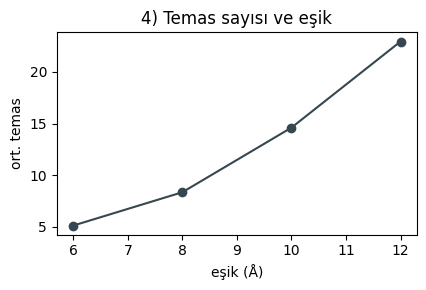

5) Heliks Cα Rg = 10.48 Å


In [14]:
# 1
print("1)", np.linalg.norm(np.array([5, 3, 12]) - np.array([2, -1, 0])))   # sqrt(9+16+144)=13
# 2
print("2)", Counter(r.get_resname() for r in kalintilar).most_common(5))
# 3
satir = []
no2idx = {r.id[1]: i for i, r in enumerate(kalintilar)}
for a, b in heliksler:
    alt = df[(df.no >= a) & (df.no <= b)]
    n = b - a + 1
    gercek = np.linalg.norm(CA[no2idx[b]] - CA[no2idx[a]])
    satir.append({"heliks": f"{a}-{b}", "uzunluk": n, "ort_phi": round(alt.phi.mean(), 1), "ort_psi": round(alt.psi.mean(), 1),
                  "beklenen_boy_A": round((n - 1) * 1.5, 1), "gercek_uzaklik_A": round(gercek, 1)})
print(pd.DataFrame(satir))
# 4
esikler = [6, 8, 10, 12]
plt.figure(figsize=(4.5, 3)); plt.plot(esikler, [((Dm < e).sum(1) - 1).mean() for e in esikler], "o-", color="#37474f")
plt.xlabel("eşik (Å)"); plt.ylabel("ort. temas"); plt.title("4) Temas sayısı ve eşik"); plt.tight_layout(); plt.show()
# 5
hCA = np.array([r["CA"].coord for r in kalintilar if heliks_mi(r.id[1])])
print("5) Heliks Cα Rg =", round(np.sqrt(((hCA - hCA.mean(0)) ** 2).sum(1).mean()), 2), "Å")